In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from google.colab import files
import io

# --- 1. Initial Loading and Data Cleaning ---
print("Please upload the file 'weatherAUS.csv' ")
uploaded = files.upload()

# Get the name of the uploaded file and read it
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Drop columns with excessive missing values to avoid model bias
cols_to_drop = ['Evaporation', 'Sunshine', 'Cloud3pm', 'Cloud9am']
df.drop(columns=cols_to_drop, inplace=True)

Por favor, sube el archivo 'weatherAUS.csv' a continuación:


Saving weatherAUS.csv to weatherAUS.csv


In [4]:
# --- 2. Handling Missing Values and Imputation ---
# Use median for numerical features and mode for categorical features
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
# --- 3. Feature Engineering ---
# Extract month and day from the Date column, then drop the original Date column
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

# Binary mapping for the target and current day rain variables
mapping = {'Yes': 1, 'No': 0}
df['RainToday'] = df['RainToday'].map(mapping)
df['RainTomorrow'] = df['RainTomorrow'].map(mapping)

# One-hot encoding for the remaining categorical variables (Location, WindDir, etc.)
df = pd.get_dummies(df, drop_first=True)

In [6]:

# --- 4. Data Splitting and Scaling ---
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler is crucial for ANN optimization and faster convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# --- 5. Neural Network Architecture Definition ---
model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid') # Sigmoid used for binary classification output
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# --- 6. Model Training ---
# Train the model while monitoring validation splits
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8422 - loss: 0.3679 - val_accuracy: 0.8519 - val_loss: 0.3503
Epoch 2/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8561 - loss: 0.3366 - val_accuracy: 0.8552 - val_loss: 0.3432
Epoch 3/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8603 - loss: 0.3290 - val_accuracy: 0.8554 - val_loss: 0.3416
Epoch 4/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8625 - loss: 0.3240 - val_accuracy: 0.8571 - val_loss: 0.3364
Epoch 5/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8635 - loss: 0.3204 - val_accuracy: 0.8575 - val_loss: 0.3374
Epoch 6/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8648 - loss: 0.3175 - val_accuracy: 0.8569 - val_loss: 0.3370
Epoch 7/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8654 - loss: 0.3151 - val_accuracy: 0.8550 - val_loss: 0.3392
Epoch 8/10
2910/2910 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8671 - loss: 0.3130 -

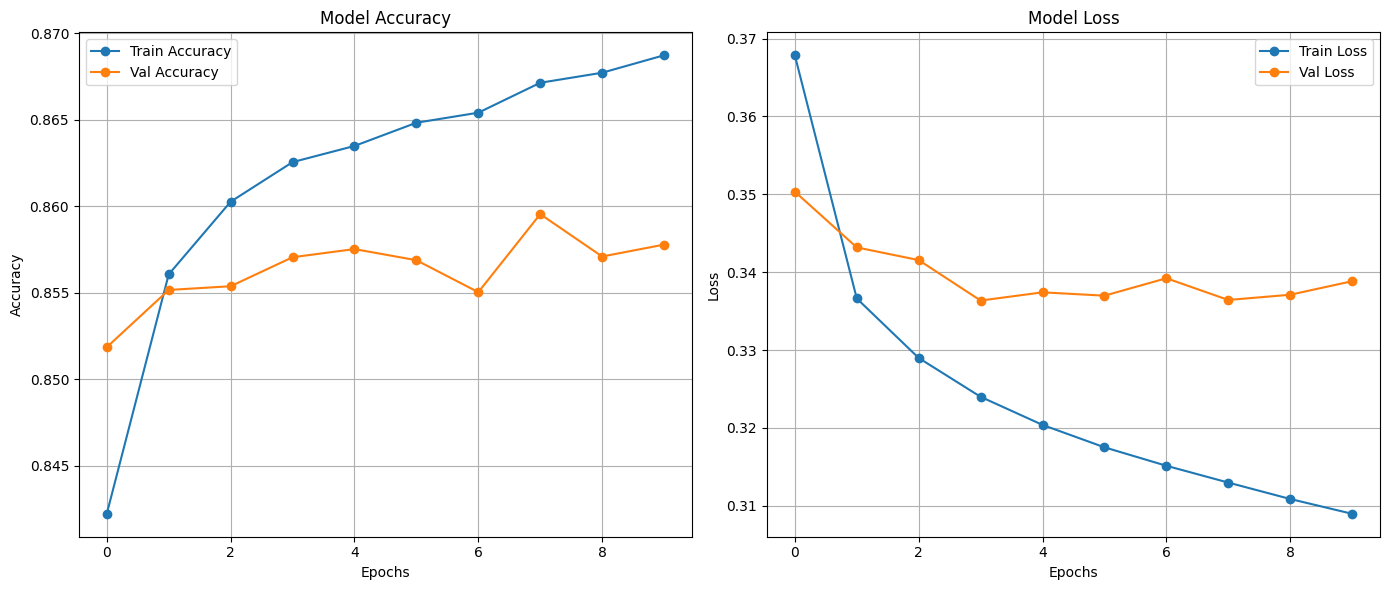

In [9]:
# --- 7. Performance Visualization ---
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(14, 6))

# Accuracy Comparison Plot
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_df['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Comparison Plot
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss', marker='o')
plt.plot(history_df['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()